# What the Score Doesn't Tell You
### A behavioral analysis of 298,000 Steam reviews

Every game on Steam wears a single number: *"85% positive."* It looks like a verdict — a clean summary of whether people liked the game. But that number hides almost everything interesting about *how* people review.

This report analyzes **298,553 reviews across 50 games** to ask what the headline score conceals. The findings are consistent and, in places, counterintuitive:

- **The refund window leaves a mark.** Reviewers who played less than two hours — the Steam refund deadline — recommend games far less often than everyone else, with a sharp cliff at exactly the two-hour line.
- **A negative review is a goodbye.** People who pan a game stop playing it within the hour; people who recommend one keep playing for hours after. The review is a leaving note or a love letter — and behavior reveals which.
- **Negativity is verbose.** Negative reviews are more than twice as long as positive ones. Complaint demands justification; praise doesn't.
- **The veteran is harsher.** Reviewers with large libraries recommend games less often — experience raises the bar.

Each finding is validated *within individual games*, not just in aggregate — a discipline that, as the next section shows, separates real effects from statistical mirages.

---
*Data collected via Steam's public review API. Pipeline, methodology, and source: [github.com/arda-basarici/ai-journey](https://github.com/arda-basarici/ai-journey).

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")
metadata = pd.read_parquet("../data/processed/metadata.parquet")

print(f"{len(reviews):,} reviews   ·   {len(metadata)} games   ·   "
      f"{reviews['language'].nunique()} languages")

298,553 reviews   ·   50 games   ·   30 languages


## The Data

These reviews were collected through Steam's public review API: up to 10,000 of the most recent reviews per game, across 50 titles spanning the spectrum from indie darlings to AAA blockbusters, free-to-play to $70 releases. After cleaning and de-duplication, **298,553 reviews** remain.

Two facts about this corpus shape everything that follows.

**It is genuinely multilingual.** Steam is global, and so is this data — English makes up just **45%** of all reviews, spread across **30 languages** in total. Russian and Simplified Chinese alone contribute another 75,000 reviews, with Spanish, Portuguese, Turkish, German, and French close behind. Review *text* was preserved exactly as written, in every script — leaving the door open to language-level analysis later.

**Reviews per game are unequal by design.** A blockbuster like Baldur's Gate 3 hits the 10,000-review ceiling; a niche title contributes a few thousand. We do not force equal counts — that would discard real data. Instead, as the next section explains, every finding in this report is computed *within each game first, then aggregated* — a method that is immune to popular titles dominating the totals.

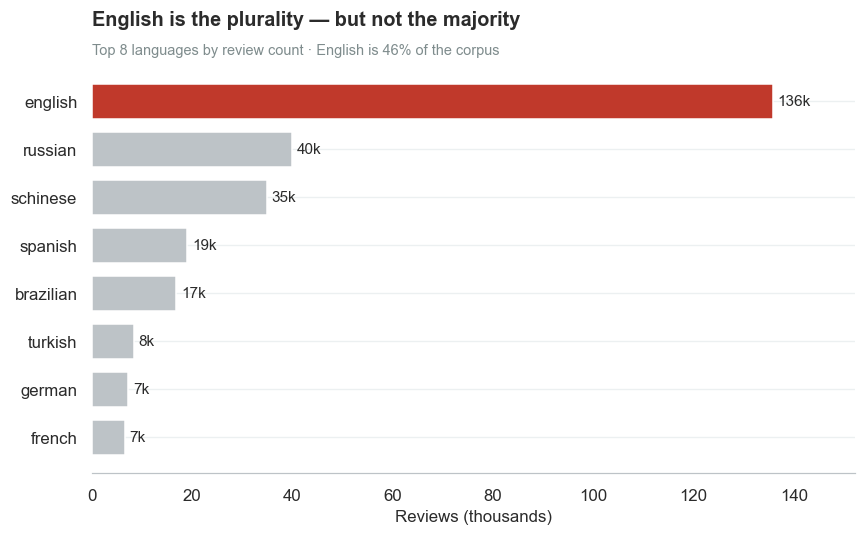

English share: 45.5%   ·   non-English: 54.5%


In [2]:
# The multilingual reality — top languages by review count
lang_counts = reviews["language"].value_counts()
top = lang_counts.head(8)
english_share = lang_counts["english"] / lang_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [_style.ACCENT if lang == "english" else _style.GREY for lang in top.index]
bars = ax.barh(top.index[::-1], top.values[::-1] / 1000,
               color=colors[::-1], height=0.72)
ax.bar_label(bars, fmt="%.0fk", padding=3, fontsize=10, color=_style.INK)

ax.set_xlabel("Reviews (thousands)")
ax.margins(x=0.12)

# title + subtitle with real spacing (no overlap)
ax.set_title(f"English is the plurality — but not the majority\n",
             loc="left", fontsize=13, fontweight="bold")
ax.text(0, 1.02, f"Top 8 languages by review count · English is {english_share:.0%} of the corpus",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")

plt.show()
print(f"English share: {english_share:.1%}   ·   non-English: {1-english_share:.1%}")

## A Note on Method: Why We Test *Within* Games

Before any finding, a word on how we separate real effects from statistical mirages — because the distinction decides what this report is willing to claim.

Here is a tempting result. Reviews written while a game was still in **Early Access** recommend at just **44.8%**, against an **87%** baseline for everything else. A 42-point gap. The obvious headline writes itself: *"reviewing an unfinished game makes people harsh."*

It is almost entirely an illusion.

The problem is **confounding by game**. Early Access reviews aren't spread evenly across our 50 titles — they're concentrated in the handful of games that *had* troubled Early Access periods. So the 44.8% isn't measuring "the effect of reviewing early." It's measuring "which games happened to be reviewed early" — and those happened to be poorly-received games. The variable is a proxy for the title, not the behavior.

The test that exposes this is simple: **does the effect hold *within* individual games?** Instead of pooling all reviews together (where popular and unpopular titles blur into one average), we ask the question separately inside each game, then see whether the answer is consistent across them. If reviewing early genuinely made people harsher, we'd see it inside game after game. We don't — there is only *one* game in the dataset with enough reviews both during and after Early Access to compare, and there the gap reverses.

So we drop the Early Access "finding" entirely. Every result in this report earns its place by surviving this same test: it must hold **within games**, not merely in aggregate. It is the difference between a pattern and an artifact — and it is the single most important habit in working with observational data.

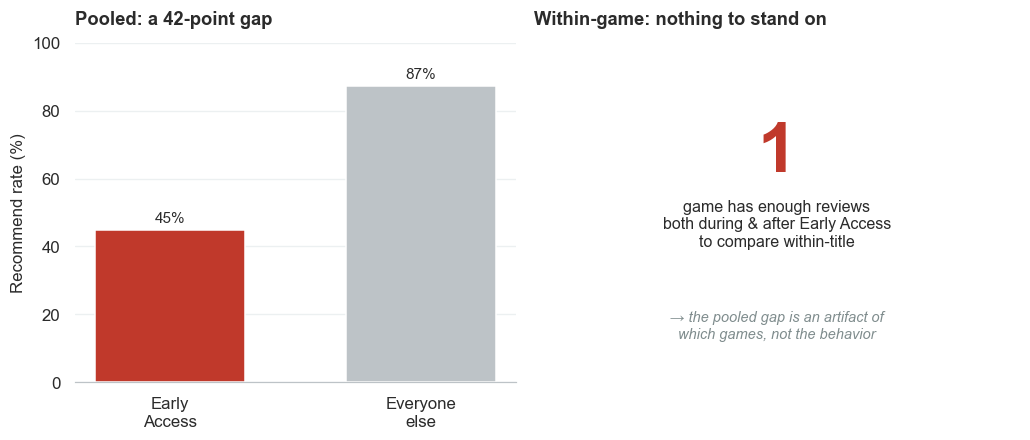

pooled EA=44.8%  non-EA=87.2%  ·  comparable games within-title: 1


In [3]:
# Demonstrate the method: Early Access looks damning POOLED, vanishes WITHIN-game
ea = reviews["written_during_early_access"] == True

pooled_ea = reviews.loc[ea, "voted_up"].mean() * 100
pooled_non = reviews.loc[~ea, "voted_up"].mean() * 100

# within-game: how many games can even be compared, and which way does it go?
gaps = _style.within_game_gap(reviews, ea, "voted_up", min_per_side=30)
# voted_up is 0/1 so the "gap" is a rate difference; scale to points
gaps_pts = gaps * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.3),
                                gridspec_kw={"width_ratios": [1, 1.1]})

# left: the seductive pooled view
ax1.bar(["Early\nAccess", "Everyone\nelse"], [pooled_ea, pooled_non],
        color=[_style.ACCENT, _style.GREY], width=0.6)
ax1.bar_label(ax1.containers[0], fmt="%.0f%%", padding=3, fontsize=10)
ax1.set_ylim(0, 100); ax1.set_ylabel("Recommend rate (%)")
ax1.set_title("Pooled: a 42-point gap", loc="left", fontsize=12)

# right: the honest within-game view
n_games = len(gaps_pts)
ax2.text(0.5, 0.62, f"{n_games}", ha="center", fontsize=46,
         color=_style.ACCENT, fontweight="bold", transform=ax2.transAxes)
ax2.text(0.5, 0.40, "game has enough reviews\nboth during & after Early Access\nto compare within-title",
         ha="center", fontsize=10.5, color=_style.INK, transform=ax2.transAxes)
ax2.text(0.5, 0.13, "→ the pooled gap is an artifact of\nwhich games, not the behavior",
         ha="center", fontsize=9.5, color=_style.GREY_DARK, style="italic", transform=ax2.transAxes)
ax2.axis("off")
ax2.set_title("Within-game: nothing to stand on", loc="left", fontsize=12)

plt.suptitle("")  # keep clean
plt.show()
print(f"pooled EA={pooled_ea:.1f}%  non-EA={pooled_non:.1f}%  ·  comparable games within-title: {n_games}")

**A note on the within-game counts.** Each within-game test includes only games with enough reviews on *both* sides of the comparison (at least 30 each) — otherwise a game's gap would rest on too few reviews to mean anything. Depending on which split a chapter tests, this leaves 46 to 48 of the 50 games qualifying. That number reflects how many games could meaningfully support each specific test, not data that was lost or discarded.

## Scope and Honest Limits

Three constraints shape what this report can and cannot say, stated up front rather than buried.

**These are recent reviews.** We collected each game's *most recent* reviews (newest first), up to 10,000 per title. This was a deliberate engineering choice — recency-ordered pagination is reliable and reproducible, where Steam's "relevance" sort is neither and skews toward already-popular reviews. The cost: for a heavily-reviewed game, 10,000 recent reviews may span only weeks or months, not its full history. We can therefore study *how people review*, but not *long-run historical trends* — a limitation we return to at the end.

**This is observational data.** We did not run an experiment; we observed reviews as they were written. That means we can establish that patterns *exist* and are *robust*, but we are careful throughout not to overclaim *causation*. Where a causal story is tempting, we name the alternative explanations rather than assuming ours.

**Fifty games is a sample, not the population.** The findings describe these 50 titles — a deliberately broad spread, but not a random draw from all of Steam. Review-level findings rest on hundreds of thousands of rows and are strong; game-level observations (anything computed across the 50 titles) rest on just 50 points and are treated as suggestive, not conclusive.

## What Follows

Four findings, each surviving the within-game test, each a facet of the same theme — *the score doesn't tell you the whole story*:

1. **The Refund Window** — recommendation rate collapses below the two-hour refund deadline, with a sharp cliff exactly at the line.
2. **A Negative Review Is a Goodbye** — sentiment predicts behavior: panners stop playing within the hour; recommenders keep going for hours after.
3. **Why Negative Reviews Are Twice as Long** — complaint demands justification; praise doesn't.
4. **The Veteran Is Harsher** — reviewers with larger libraries recommend less often.

We close with the findings we *declined* to make — the tempting results that didn't survive scrutiny — because what an analysis refuses to claim is as much a measure of its honesty as what it does.